<center><h1>Keehan_Alyssa_HW2</h1></center>
<br>
<br>

**Name:** Alyssa Keehan
**GitHub Username:** akeehan56  
**Email:** akeehan@usc.edu  
**USC ID:** 3429542433

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ! pip install pandas openpyxl
# ! pip install pandas statsmodels


Get the Cycle Power Plant Data Set

In [4]:
df = pd.read_excel("../Data/CCPP/Folds5x2_pp.xlsx")
print(df.head())


      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


### (b) Exploring the data

#### i. rows and columns

In [7]:
df.shape

(9568, 5)

**Answer**:

There are **5** **columns** and **9,568** **rows** in this dataset. 

The columns represent the 5 different features related to the Combined Cycle Power Plate (CCPP) over the years of 2006-2011. The rows are the hourly averages of these featuresfrom that 6 year window. The independent features include Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V), which are all used to predict dependent variable, the net hourly electrical energy output (PE) of the plant.

#### ii. pairwise scatterplots of all the varianbles

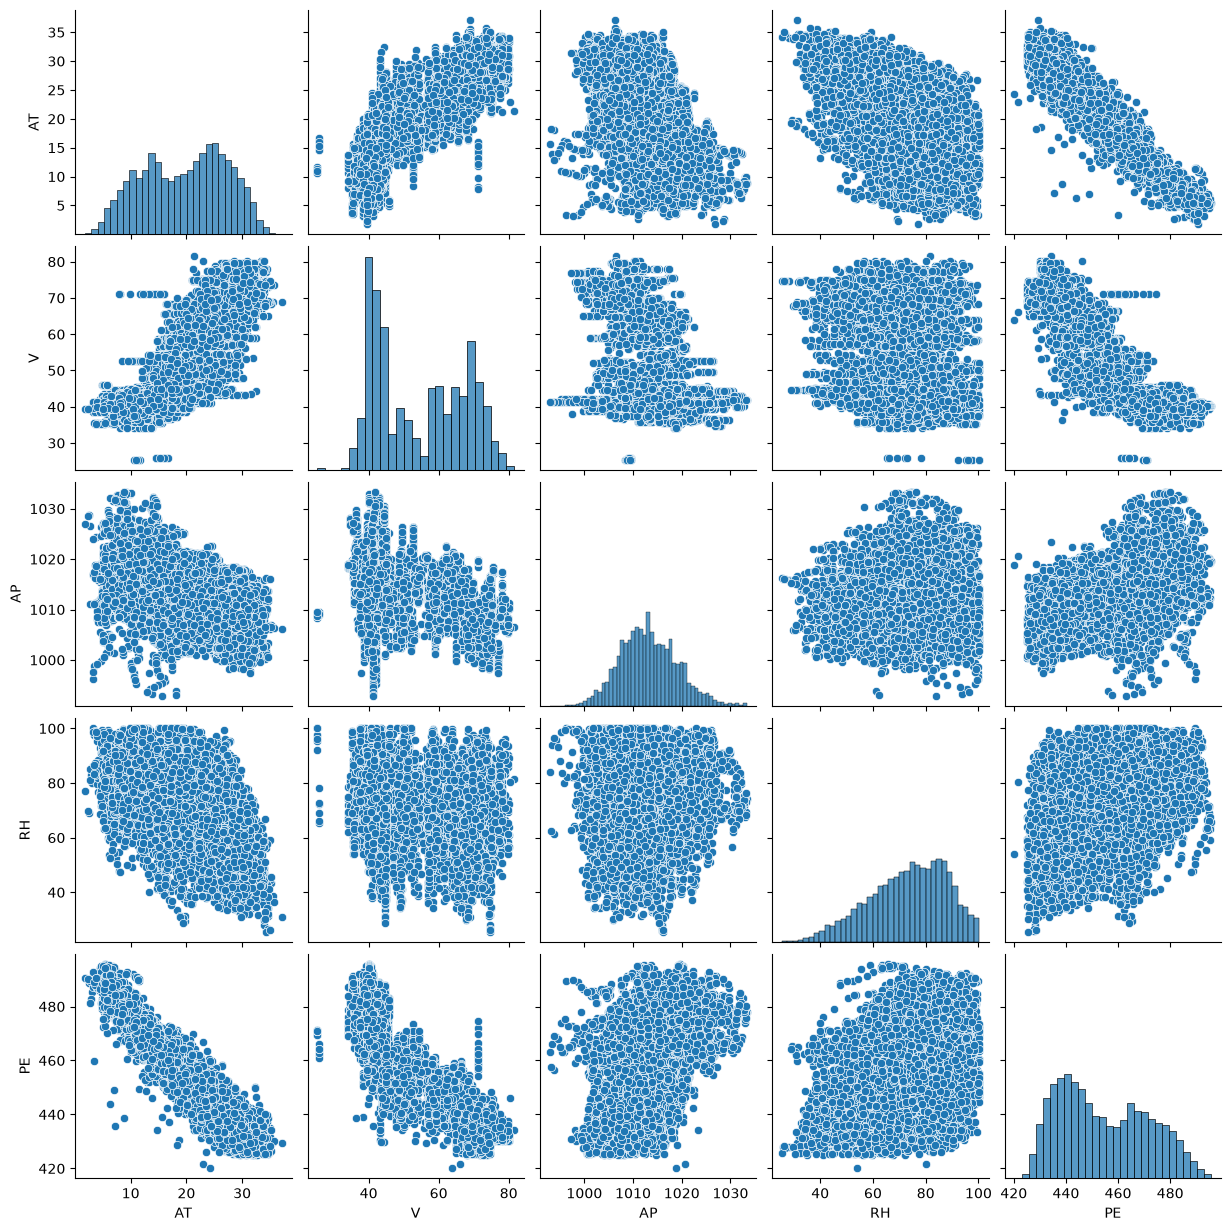

In [8]:

sns.pairplot(
    df,
    vars=df.columns,
    diag_kind="hist"
)

plt.show()

**Answer:**

The two variables with the strongest linear relationship are Average Temperature (AT) and Net Hourly Electrical Energy Output of the Plant (PE), which seems to show a negative relationship. This indicates that as Average Temperature increases, the net hourly energy output decreases. 

The next strongest relationship we're seeing is Exhaust Vaccuum (V) vs. energy output (PE), also showing a slight negative relationship between the two variables. 

All other variable combinations show little to no liner relationship, with even distribution of data points across the whole graph, indicating that an increase/decrease in one of the fields doesn't necessarily correlate with an increase/decrease in the other. 

In terms of normal distribution for each of the variables, average temperature (AT), Exhaust Vaccuum (V) and out dependent variable net hourly electrial energy output (PE) all show a bimodal distribution. Ambient Pressure (AP) shows a normal distribution and Relative Humidity (RH) shows a left skewed distribution. 

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [11]:
summary = df.describe()
summary.loc['range'] = summary.loc['max'] - summary.loc['min']
summary.loc['IQR'] = summary.loc['75%'] - summary.loc['25%']
final_metrics = summary.loc[['mean', '50%', 'range', '25%', '75%', 'IQR']].round(2)
final_metrics 

,AT,V,AP,RH,PE
mean,19.65,54.31,1013.26,73.31,454.37
50%,20.34,52.08,1012.94,74.97,451.55
range,35.30,56.20,40.41,74.60,75.50
25%,13.51,41.74,1009.10,63.33,439.75
75%,25.72,66.54,1017.26,84.83,468.43
IQR,12.21,24.80,8.16,21.50,28.68


### (c) Simple Linear Regression

***AI Notes***

I used AI to help structure the code with statsmodels since I'm unfamiliar with this package. I'm used to leveraging skikit learn for ML methods / functions. 

The prompt I used was "I'm supposed to use statsmodel to fit a simple linear and multiple regression model to my data. What packages do I need and what is the stater code to set that up?"

The following pieces of code were built from the stater code received as a response from chat. 

In [34]:
independent_variables = df.columns.drop("PE")

results = []

for variable in independent_variables:

    simple_model = smf.ols(
        formula=f"PE ~ {variable}",
        data=df
    ).fit()

    confidence_intervals = simple_model.conf_int()

    results.append({
        "Predictor": variable,
        "R-squared": simple_model.rsquared,
        "Intercept": simple_model.params["Intercept"],
        "Coefficient": simple_model.params[variable],
        "Coefficient Std. Error": simple_model.bse[variable],
        "p-value": simple_model.pvalues[variable],
        "95% CI Lower": confidence_intervals.loc[variable, 0],
        "95% CI Upper": confidence_intervals.loc[variable, 1],
    })

simple_regression_summary = pd.DataFrame(results)

simple_regression_summary

,Predictor,R-squared,Intercept,Coefficient,Coefficient Std. Error,p-value,95% CI Lower,95% CI Upper
0,AT,0.898948,497.034120,-2.171320,0.007443,0.0,-2.185910,-2.156730
1,V,0.756518,517.801526,-1.168135,0.006776,0.0,-1.181417,-1.154853
2,AP,0.268769,-1055.260989,1.489872,0.025126,0.0,1.440620,1.539124
3,RH,0.151939,420.961766,0.455650,0.011006,0.0,0.434075,0.477225


**Answer:**
* All four predictors produce a ($p<0.001$) and the confidence interals do not cross over 0, so we can reject the null hypothesis that $H_0: \beta_j = 0$ for all predictors in their individual simple linear regression eqations. This could be the result of having a large sample size of 9.6K which reduces standard errors. 
* Like mentioned in an earlier question, the strongest linear relationship is between Average Temperature and Energy Output, with an $R^2$ of 0.899 indicating that Average temperature explains 89.9% of the variability in Energy Output. 
* Exhaust Vaccum also produced a high $R^2$ of 0.757 indicating that it explains 75.7% fo the variability in Energy Output. 
* Both Ambient Pressure and Relative Humidity produced low $R^2$ values (< 50%) which indicate relatively weak linear relationships with the outcome variable. 

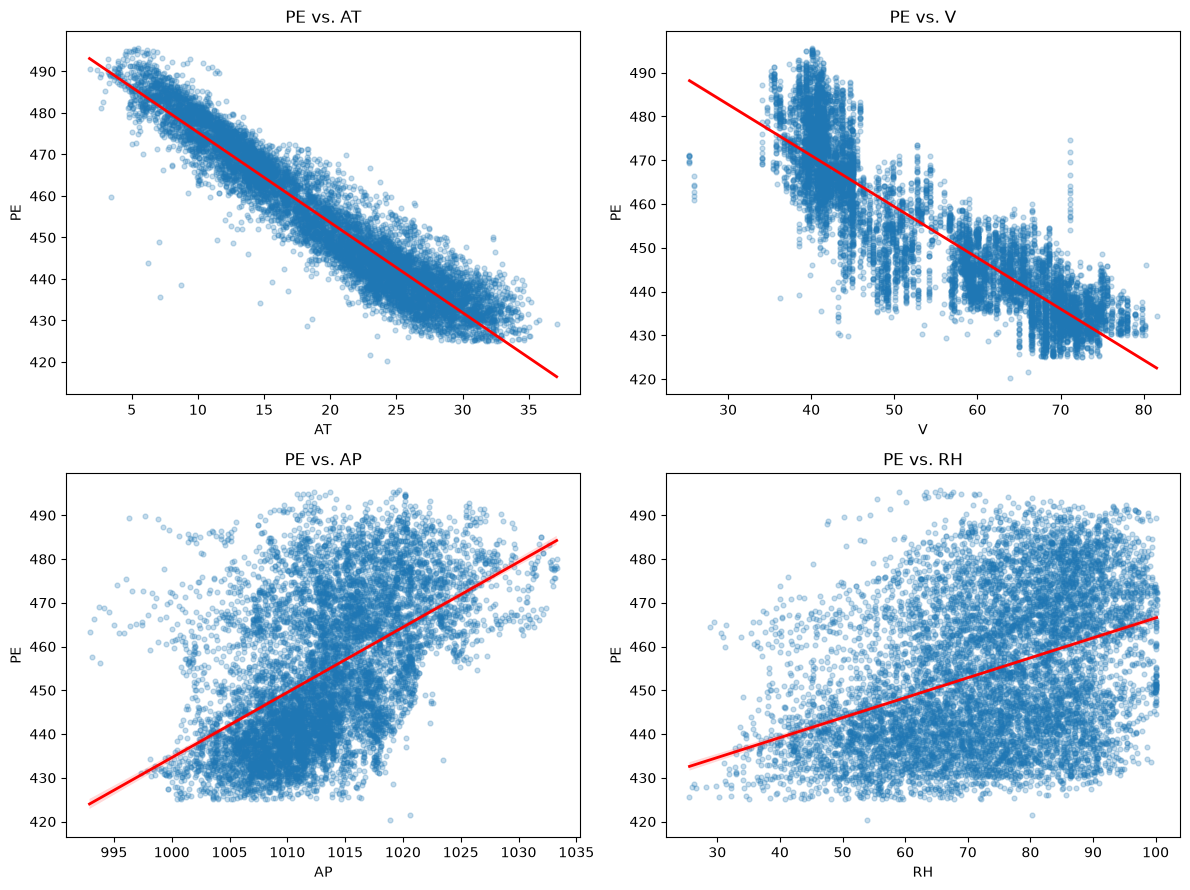

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(independent_variables, axes.flatten()):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        scatter_kws={"alpha": 0.25, "s": 12},
        line_kws={"color": "red", "linewidth": 2},
        ax=ax
    )

    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

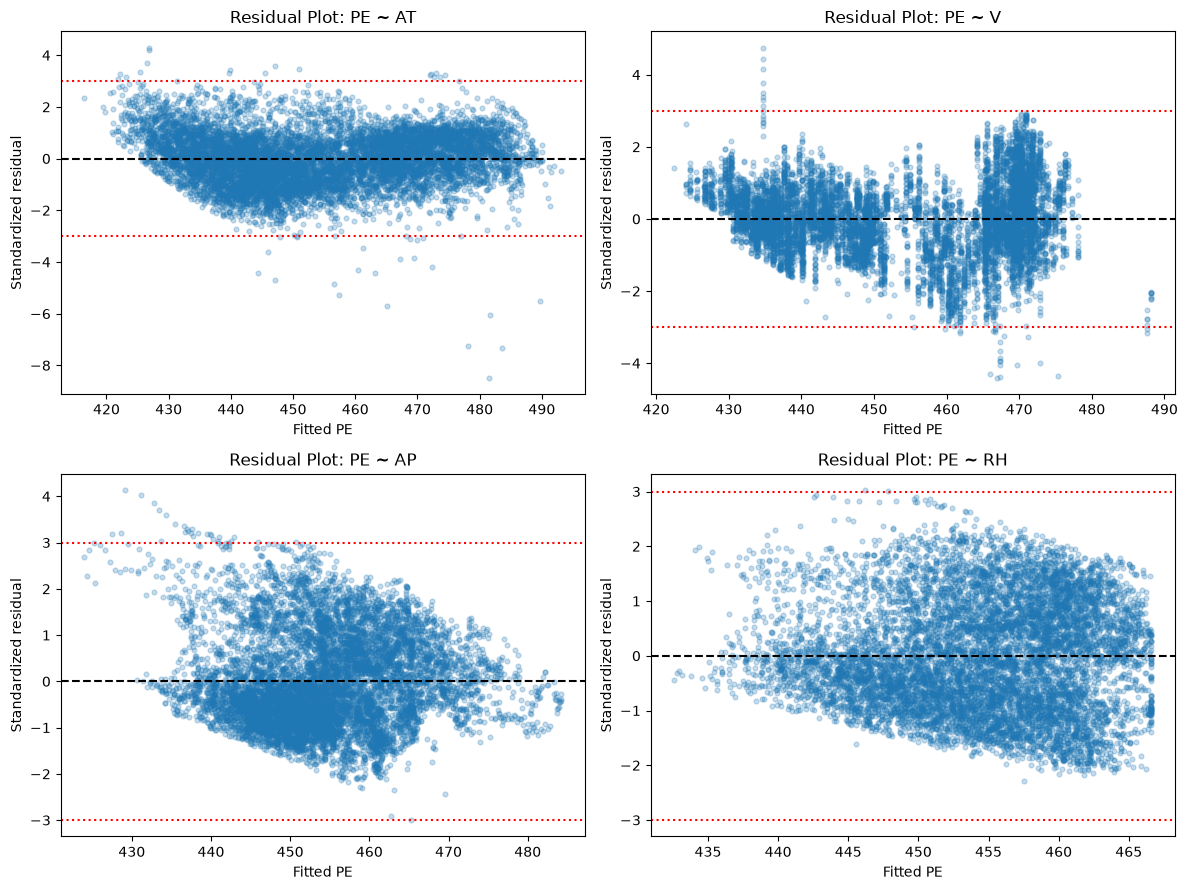

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(independent_variables, axes.flatten()):
    model = smf.ols(f"PE ~ {predictor}", data=df).fit()
    influence = model.get_influence()
    standardized_residuals = influence.resid_studentized_internal

    ax.scatter(
        model.fittedvalues,
        standardized_residuals,
        alpha=0.25,
        s=12
    )

    ax.axhline(0, color="black", linestyle="--")
    ax.axhline(3, color="red", linestyle=":")
    ax.axhline(-3, color="red", linestyle=":")
    ax.set_title(f"Residual Plot: PE ~ {predictor}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Standardized residual")

plt.tight_layout()
plt.show()

**Answer:**
* Above are standardized resiudal plots which are intended to point out any observations that could be considered outliers (> 3 standard devations).
* Interestingly enough, there are more outliers for the predictors with a stronger relationship with Energy Output, which may be because of small residual variation, as points that depart from a tigher, stronger model stand out more clearly. This does not mean that stronger relationships inherently produce more outliers.
* Because the overall range of PE still happens to be around 420-490, there's not enough clear indication of a mistake in data entry that would influence us to remove any outliers. Unless further investigation shows that they are erroneous or highly influential, they should remain in the dataset.

### (d) Multiple Regression

In [40]:
multiple_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:32:20   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Answer:**

The fitted multiple linear regression equation is:
$$
\widehat{PE}
= 454.6093 - 1.9775(AT) - 0.2339(V) + 0.0621(AP) - 0.1581(RH)
$$

The model has an $R^2$ of 0.929, meaning that the predictors collectively account for 92.9% of the variability in PE. The overall model is statistically significant ($p<0.001$).

Holding the other predictors constant, AT, V, and RH have negative associations with PE, while AP has a positive association. All predictors have p-values below 0.001 and confidence intervals that do not contain zero. Therefore, we reject $H_0:\beta_j=0$ for all four predictors.

Notably, the coefficient for RH changed from positive in the simple regression to negative in the multiple regression, indicating that its relationship with PE is affected by the other predictors.


### (e) 1c Compare to 1d

In [45]:
# Pull the coefficients from results from 1c and 1d
coefficient_comparison = (
    simple_regression_summary
    .set_index("Predictor")[["Coefficient"]]
    .rename(columns={"Coefficient": "Simple Regression"})
)

coefficient_comparison["Multiple Regression"] = (
    multiple_model.params.reindex(coefficient_comparison.index)
)

coefficient_comparison["Absolute Difference"] = (
    coefficient_comparison["Simple Regression"]
    - coefficient_comparison["Multiple Regression"]
).abs()

coefficient_comparison

,Simple Regression,Multiple Regression,Absolute Difference
Predictor,,,
AT,-2.171320,-1.977513,0.193807
V,-1.168135,-0.233916,0.934219
AP,1.489872,0.062083,1.427789
RH,0.455650,-0.158054,0.613704


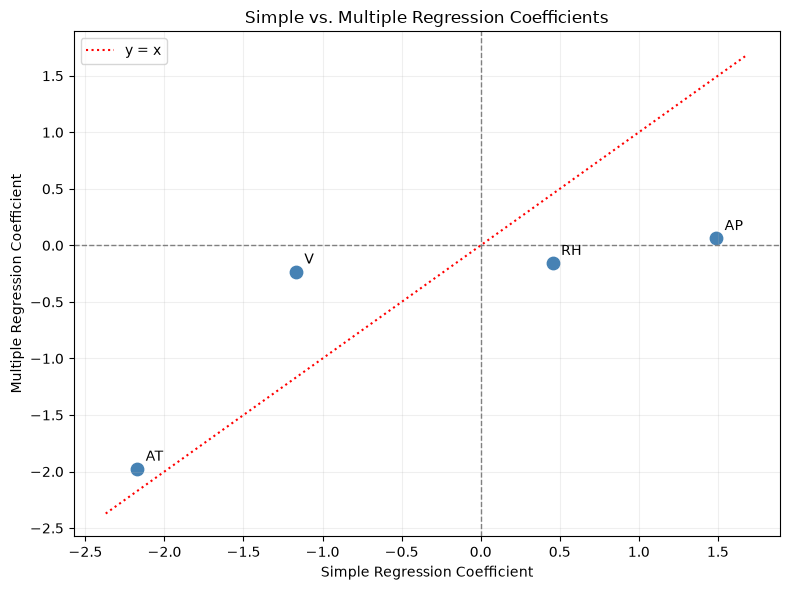

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

x = coefficient_comparison["Simple Regression"]
y = coefficient_comparison["Multiple Regression"]

ax.scatter(x, y, color="steelblue", s=80)

# Label each point
for predictor in coefficient_comparison.index:
    ax.annotate(
        predictor,
        (x.loc[predictor], y.loc[predictor]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Reference lines
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)

# y = x reference line
minimum = min(x.min(), y.min()) - 0.2
maximum = max(x.max(), y.max()) + 0.2

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle=":",
    label="y = x"
)

ax.set_xlabel("Simple Regression Coefficient")
ax.set_ylabel("Multiple Regression Coefficient")
ax.set_title("Simple vs. Multiple Regression Coefficients")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Answer:**

* Average Temperature (AT) had the smallest absolute change, moving from −2.17 in the simple regression to −1.98 in the multiple regression, a difference of approximately 0.19. Its association with PE remained negative.
* Exhaust Vacuum (V) changed from −1.17 to −0.23, becoming substantially less negative after controlling for the other predictors.
* Ambient Pressure (AP) had the largest absolute change, decreasing from 1.49 to 0.06, a difference of approximately 1.43. However, its association with PE remained positive.
* Relative Humidity (RH) changed direction, moving from 0.46 in the simple regression to −0.16 in the multiple regression. This is notable because it indicates that the association between RH and PE becomes negative after controlling for the other predictors.

### (f) Nonlinear Association

### (g) Interactions of Predictors

### (h) Improvement

### (i) KNN

### (j ) Compare KNN and Linear

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

### (c) The relationship between the predictors and response is highly non-linear.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

### (b) What is our prediction with K = 1? Why?

### (c) What is our prediction with K = 3? Why?

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?